<a href="https://colab.research.google.com/github/shu-admin/sun.github.io/blob/master/covid_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
#导入pandas库

全球疫情的可视化分析及预测

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


从网上搜集到的全球疫情数据中，进行预处理，筛选出中国和印度的数据

**导入中国、印度数据**

In [ ]:
china_data = pd.read_excel('/content/drive/MyDrive/疫情数据/China.xlsx',index_col=None,header=0)
india_data = pd.read_excel('/content/drive/MyDrive/疫情数据/India.xlsx',index_col=None,header=0)

In [ ]:
print(china_data)

    location        date  total_cases  total_deaths
0      China  2020-01-22          548            17
1      China  2020-01-23          643            18
2      China  2020-01-24          920            26
3      China  2020-01-25         1406            42
4      China  2020-01-26         2075            56
..       ...         ...          ...           ...
477    China  2021-05-13       102681          4846
478    China  2021-05-14       102696          4846
479    China  2021-05-15       102717          4846
480    China  2021-05-16       102746          4846
481    China  2021-05-17       102769          4846

[482 rows x 4 columns]


In [ ]:
print(india_data)

    location        date  total_cases  total_deaths
0      India  2020-01-30            1           NaN
1      India  2020-01-31            1           NaN
2      India  2020-02-01            1           NaN
3      India  2020-02-02            2           NaN
4      India  2020-02-03            3           NaN
..       ...         ...          ...           ...
469    India  2021-05-13     24046809      262317.0
470    India  2021-05-14     24372907      266207.0
471    India  2021-05-15     24684077      270284.0
472    India  2021-05-16     24965463      274390.0
473    India  2021-05-17     25228996      278719.0

[474 rows x 4 columns]


缺失数据清洗

In [ ]:
china_data.dropna()

,location,date,total_cases,total_deaths
0,China,2020-01-22,548,17
1,China,2020-01-23,643,18
2,China,2020-01-24,920,26
3,China,2020-01-25,1406,42
4,China,2020-01-26,2075,56
...,...,...,...,...
477,China,2021-05-13,102681,4846
478,China,2021-05-14,102696,4846
479,China,2021-05-15,102717,4846
480,China,2021-05-16,102746,4846


In [ ]:
india_data.dropna()

,location,date,total_cases,total_deaths
41,India,2020-03-11,62,1.0
42,India,2020-03-12,73,1.0
43,India,2020-03-13,82,2.0
44,India,2020-03-14,102,2.0
45,India,2020-03-15,113,2.0
...,...,...,...,...
469,India,2021-05-13,24046809,262317.0
470,India,2021-05-14,24372907,266207.0
471,India,2021-05-15,24684077,270284.0
472,India,2021-05-16,24965463,274390.0


**获取16个日期的样本点（间隔一月）**

In [ ]:
china_date_list=[]
for i in range(2,18):
  if i < 10:
    china_date_list.append('2020-0'+str(i)+'-01')
  elif i < 13:
    china_date_list.append('2020-'+str(i)+'-01')
  else:
    china_date_list.append('2021-0'+str(i%12)+'-01')
    
print(china_date_list)

['2020-02-01', '2020-03-01', '2020-04-01', '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01', '2020-11-01', '2020-12-01', '2021-01-01', '2021-02-01', '2021-03-01', '2021-04-01', '2021-05-01']


In [ ]:
india_date_list=[]
for i in range(3,18):
  if i < 10:
    india_date_list.append('2020-0'+str(i)+'-11')
  elif i < 13:
    india_date_list.append('2020-'+str(i)+'-11')
  else:
    india_date_list.append('2021-0'+str(i%12)+'-11')
    
print(india_date_list)

['2020-03-11', '2020-04-11', '2020-05-11', '2020-06-11', '2020-07-11', '2020-08-11', '2020-09-11', '2020-10-11', '2020-11-11', '2020-12-11', '2021-01-11', '2021-02-11', '2021-03-11', '2021-04-11', '2021-05-11']


统计各个时间样本点的患病总人数、死亡总人数

In [ ]:
l1=[]
l2=[]
for i in range(471):
  # print(data['date'][i])
  if china_data['date'][i] in china_date_list:
    l1.append(china_data['total_cases'][i])
    l2.append(china_data['total_deaths'][i])
for i in range(16):
  print(str(china_date_list[i])+' : '+'总人数：'+str(l1[i])+' 总死亡人数：'+str(l2[i]))

2020-02-01 : 总人数：11891 总死亡人数：259
2020-03-01 : 总人数：79932 总死亡人数：2872
2020-04-01 : 总人数：82361 总死亡人数：3316
2020-05-01 : 总人数：83959 总死亡人数：4637
2020-06-01 : 总人数：84154 总死亡人数：4638
2020-07-01 : 总人数：84816 总死亡人数：4641
2020-08-01 : 总人数：87827 总死亡人数：4667
2020-09-01 : 总人数：89933 总死亡人数：4724
2020-10-01 : 总人数：90567 总死亡人数：4739
2020-11-01 : 总人数：91397 总死亡人数：4739
2020-12-01 : 总人数：92993 总死亡人数：4743
2021-01-01 : 总人数：96023 总死亡人数：4782
2021-02-01 : 总人数：100127 总死亡人数：4818
2021-03-01 : 总人数：100990 总死亡人数：4836
2021-04-01 : 总人数：101754 总死亡人数：4841
2021-05-01 : 总人数：102517 总死亡人数：4846


In [ ]:
l3=[]
l4=[]
for i in range(473):
  # print(data['date'][i])
  if india_data['date'][i] in india_date_list:
    l3.append(india_data['total_cases'][i])
    l4.append(india_data['total_deaths'][i])
for i in range(15):
  print(str(india_date_list[i])+' : '+'总人数：'+str(l3[i])+' 总死亡人数：'+str(l4[i]))

2020-03-11 : 总人数：62 总死亡人数：1.0
2020-04-11 : 总人数：8446 总死亡人数：288.0
2020-05-11 : 总人数：70768 总死亡人数：2294.0
2020-06-11 : 总人数：297535 总死亡人数：8498.0
2020-07-11 : 总人数：849522 总死亡人数：22673.0
2020-08-11 : 总人数：2329638 总死亡人数：46091.0
2020-09-11 : 总人数：4659984 总死亡人数：77472.0
2020-10-11 : 总人数：7120538 总死亡人数：109150.0
2020-11-11 : 总人数：8683916 总死亡人数：128121.0
2020-12-11 : 总人数：9826775 总死亡人数：142628.0
2021-01-11 : 总人数：10479179 总死亡人数：151327.0
2021-02-11 : 总人数：10880603 总死亡人数：155447.0
2021-03-11 : 总人数：11308846 总死亡人数：158306.0
2021-04-11 : 总人数：13527717 总死亡人数：170179.0
2021-05-11 : 总人数：23340938 总死亡人数：254197.0


**绘制图形**
导入matplotlib库进行图形的绘制

Text(2, 70000, 'inflecion point')

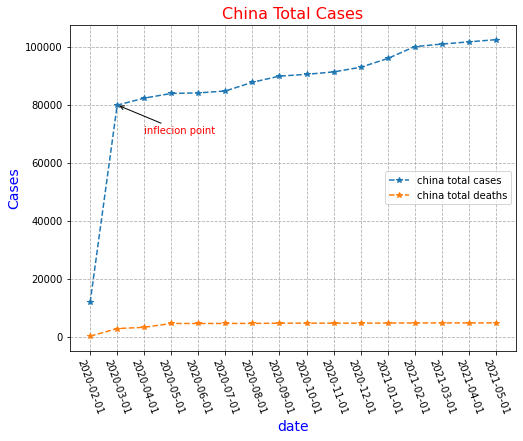

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
# plt.plot(new_list,l1,l3,'*')
plt.plot(china_date_list,l1,'*',linestyle='dashed',label='china total cases')#添加label设置图例名称
plt.plot(china_date_list,l2,'*',linestyle='dashed',label='china total deaths')#添加label设置图例名称
plt.title('China Total Cases',c='r',fontsize=16)
plt.xlabel('date',c='b',fontsize=14)
plt.ylabel('Cases',c='b',fontsize=14)
plt.xticks(rotation=290)
plt.legend(loc='right')#添加图例
plt.grid(linestyle='dashed')#添加网格线
plt.annotate('inflecion point',xy=(1,80000),xytext=(2,70000),c='r',arrowprops=dict(arrowstyle='->'))#添加拐点注释


Text(14, 15000000, 'inflecion point')

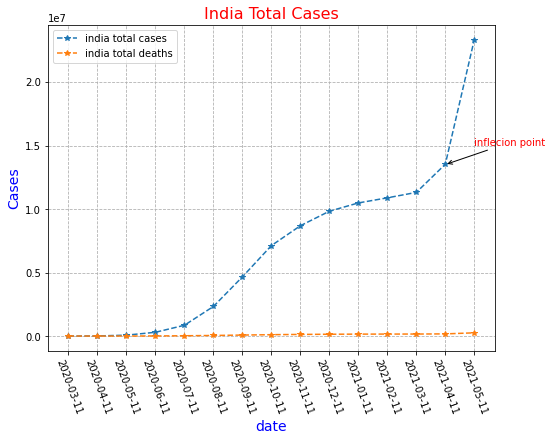

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
# plt.plot(new_list,l1,l3,'*')
plt.plot(india_date_list,l3,'*',linestyle='dashed',label='india total cases')#添加label设置图例名称
plt.plot(india_date_list,l4,'*',linestyle='dashed',label='india total deaths')#添加label设置图例名称
plt.title('India Total Cases',c='r',fontsize=16)
plt.xlabel('date',c='b',fontsize=14)
plt.ylabel('Cases',c='b',fontsize=14)
plt.xticks(rotation=290)
plt.legend(loc='best')#添加图例
plt.grid(linestyle='dashed')#添加网格线
plt.annotate('inflecion point',xy=(13,13500000),xytext=(14,15000000),c='r',arrowprops=dict(arrowstyle='->'))#添加拐点注释


**由于患病总人数和死亡总人数数量级差距较大，于是我选择采用twinx()双y轴的方法**

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  


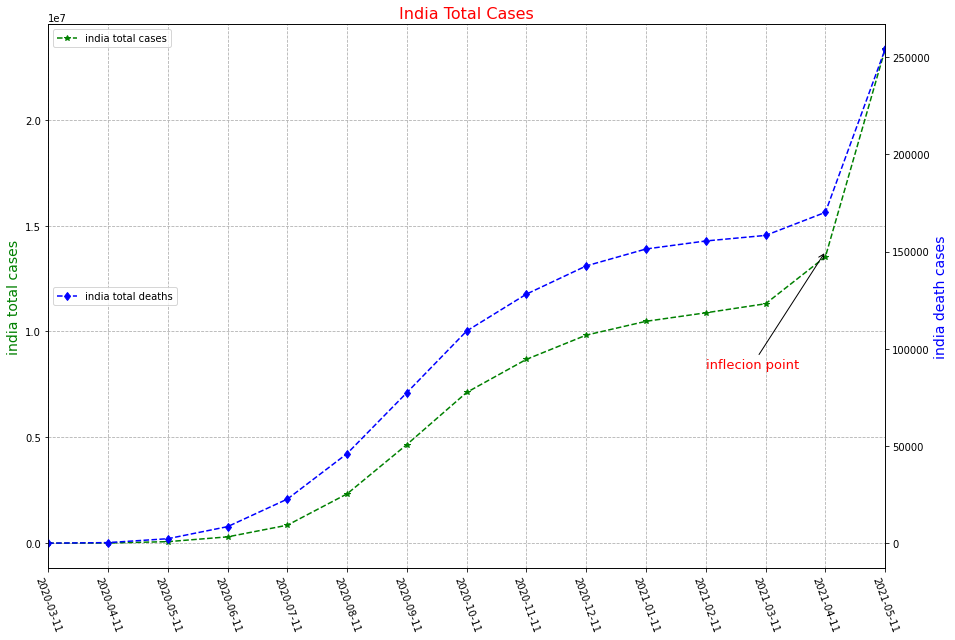

In [ ]:
x = india_date_list
fig = plt.figure(figsize=(15,10))
plt.grid(linestyle='dashed')
plt.xticks(rotation=290)

ax1 = fig.add_subplot(111)
ax1.plot(x, l3,'*',linestyle='dashed',c='green',label='india total cases')
ax1.set_ylabel('india total cases',c='green',fontsize=14)
ax1.set_title('India Total Cases',c='r',fontsize=16)
plt.legend(loc='upper left')#添加图例

ax2 = ax1.twinx()  # this is the important function
ax2.plot(x, l4,'d',linestyle='dashed',c='b',label='india total deaths')
ax2.set_xlim([0, 14])#设置x轴区间
ax2.set_ylabel('india death cases',fontsize=14,c='b')
ax2.set_xlabel('Same X for both exp(-x) and ln(x)')
plt.legend(loc='center left')#添加图例
plt.annotate('inflecion point',fontsize=13,xy=(13,150000),xytext=(11,90000),c='r',arrowprops=dict(arrowstyle='->'))#添加拐点注释
plt.show()

**疫情预测**

**通过多项式拟合，进行疫情的预测**

通过拟合可以预测6月11日印度的患病人数：24326367.02718406


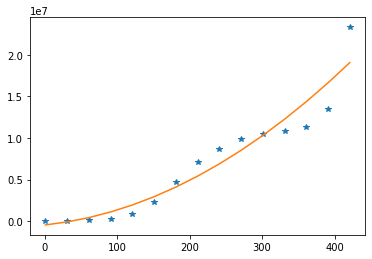

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
#将日期对应于数字，进行多项式拟合 
x_india_data = np.arange(1,450,30)
# print(x_india_data)
y_india_data = np.array(l3)
# print(y_india_data) 
 
poly = np.polyfit(x_india_data, y_india_data, deg = 2)
plt.plot(x_india_data, y_india_data, '*')
print('通过拟合可以预测6月11日印度的患病人数：'+str(np.polyval(poly,480)))
plt.plot(x_india_data, np.polyval(poly, x_india_data))
plt.show()

**通过导入pyecharts库绘制全球疫情地图**

**绘制疫情地图**

In [ ]:
# 导入pyecharts第三方库
from pyecharts.charts import * 
from pyecharts import options as opts
world_map = (
    Map()
    .add('', [list(z) for z in zip(world_data.country, world_data.confirm)], 'world')
    .set_series_opts(label_opts=opts.LabelOpts(is_show=False))
    .set_global_opts(
            # 标题
            title_opts=opts.TitleOpts(title="世界地图疫情分布图"),
            tooltip_opts=opts.TooltipOpts(formatter='{b}: {c}'),
            # 视觉效果
            visualmap_opts=opts.VisualMapOpts(is_piecewise=True,
                                              pieces=[
                                                  {'min': 201, 'label': '>200', "color": "#893448"},
                                                  {'min': 51, 'max': 200, 'label': '51-200', "color": "#ff585e"},
                                                  {'min': 21, 'max': 50, 'label': '21-50', "color": "#ffb248" },
                                                  {'min': 11, 'max': 20, 'label': '11-20', "color": "#ffb248"},
                                                  {'min': 1, 'max': 10,'label': '1-10', "color" : "#fff2d1" }
                                              ]),
        )
)


# 将世界疫情分布图存储进world_map.html

'/content/drive/MyDrive/疫情数据/world_map.html'